In [1]:
import os
import sys
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics
import tensorflow.keras
import tensorflow.keras.layers as layers
import IPython.display as ipd
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt




print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("librosa version:", librosa.__version__)
print("TensorFlow version:", tf.__version__)

Python version: 3.8.20 (default, Oct  3 2024, 15:19:54) [MSC v.1929 64 bit (AMD64)]
NumPy version: 1.19.5
librosa version: 0.9.2
TensorFlow version: 2.5.3


In [2]:
def preprocess_file(song_path, n_mfcc=128, num_segments=14):
    """
    Preprocess a single song into MFCC feature segments.
    Each segment is reshaped to (16, 8, 1).
    """
    mfcc_segments = []

    try:
        duration = librosa.get_duration(filename=song_path)

        if duration > 90:  # longer than 1.5 minutes
            audio, sr = librosa.load(
                song_path,
                sr=None,
                offset=30,
                duration=60
            )
        else:
            audio, sr = librosa.load(song_path, sr=None)

        total_samples = len(audio)
        segment_length = total_samples // num_segments

        for s in range(num_segments):
            start = s * segment_length
            end = start + segment_length
            segment = audio[start:end]

            if len(segment) < segment_length // 2:
                continue

            mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc)
            mfcc_mean = np.mean(mfcc.T, axis=0)
            mfcc_reshaped = np.reshape(mfcc_mean, (16, 8, 1))
            mfcc_segments.append(mfcc_reshaped)

    except Exception as e:
        print(f"Error processing {song_path}: {e}")

    return mfcc_segments


def preprocess_dataset(parent_dir, genres, n_mfcc=128, num_segments=14, max_files=None):
    dataset = []
    labels = []

    for genre, genre_number in genres.items():
        genre_dir = os.path.join(parent_dir, genre)
        print(f"Processing genre: {genre}")

        files = [f for f in os.listdir(genre_dir) if f.endswith((".wav", ".au", ".mp3"))]
        if max_files:
            files = files[:max_files]

        for filename in files:
            song_path = os.path.join(genre_dir, filename)
            mfcc_segments = preprocess_file(song_path, n_mfcc, num_segments)

            dataset.extend(mfcc_segments)
            labels.extend([genre_number] * len(mfcc_segments))

    dataset = np.array(dataset)
    labels = np.array(labels)

    print("Final dataset shape:", dataset.shape)
    print("Final labels shape:", labels.shape)
    return dataset, labels

In [3]:
Xcheck= preprocess_file("data/genresWAV/classical/classical.00003.wav")
print(np.array(Xcheck).shape)

(14, 16, 8, 1)


In [4]:
genres = {
    'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4,
    'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9
}

X, y = preprocess_dataset("data/genresWAV", genres)

Processing genre: blues
Processing genre: classical
Processing genre: country
Processing genre: disco
Processing genre: hiphop
Processing genre: jazz
Processing genre: metal
Processing genre: pop
Processing genre: reggae
Processing genre: rock
Final dataset shape: (14000, 16, 8, 1)
Final labels shape: (14000,)


In [5]:
X.shape

(14000, 16, 8, 1)

In [6]:
labelencoder = LabelEncoder()
y = to_categorical(labelencoder.fit_transform(y))


from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [10]:
INPUTSHAPE = (16,8,1)
model = Sequential([

    layers.Conv2D(50 , (3,3),activation = 'relu',padding='valid', input_shape = INPUTSHAPE),
    layers.MaxPooling2D(2, padding='same'),
    layers.Flatten(),
    layers.Dense(421, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dense(10 , activation = 'softmax')
])

model.compile(loss = 'categorical_crossentropy', optimizer
=tf.keras.optimizers.Adam(learning_rate=0.0010486934124383427)
#= 'adam'
, metrics =['accuracy'])
model.summary()


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 14, 6, 50)         500       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 7, 3, 50)          0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 1050)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 421)               442471    
_________________________________________________________________
dense_5 (Dense)              (None, 10)                4220      
Total params: 447,191
Trainable params: 447,191
Non-trainable params: 0
_________________________________________________________________


In [11]:

batch_size = 128
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', min_delta=0, patience=8, verbose=0, mode='auto',
    baseline=None, restore_best_weights=False)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1)
#checkpointer = ModelCheckpoint(filepath='saved_models/audio_classification.hdf5',
                             # verbose=1, save_best_only=True)
history = model.fit(X_train,y_train ,validation_data=(X_test,y_test),
            epochs=50,
            verbose=1,
            callbacks = [lr_scheduler],batch_size=batch_size)

Epoch 1/50
77/77 [==============================] - 2s 15ms/step - loss: 1.8340 - accuracy: 0.4626 - val_loss: 1.2425 - val_accuracy: 0.5912
Epoch 2/50
77/77 [==============================] - 1s 15ms/step - loss: 1.0954 - accuracy: 0.6447 - val_loss: 1.1084 - val_accuracy: 0.6436
Epoch 3/50
77/77 [==============================] - 1s 14ms/step - loss: 0.9226 - accuracy: 0.7051 - val_loss: 0.9208 - val_accuracy: 0.7114
Epoch 4/50
77/77 [==============================] - 1s 14ms/step - loss: 0.7794 - accuracy: 0.7610 - val_loss: 0.8691 - val_accuracy: 0.7205
Epoch 5/50
77/77 [==============================] - 1s 14ms/step - loss: 0.7026 - accuracy: 0.7808 - val_loss: 0.8484 - val_accuracy: 0.7355
Epoch 6/50
77/77 [==============================] - 1s 15ms/step - loss: 0.5949 - accuracy: 0.8209 - val_loss: 0.6929 - val_accuracy: 0.7871
Epoch 7/50
77/77 [==============================] - 2s 23ms/step - loss: 0.5060 - accuracy: 0.8536 - val_loss: 0.6882 - val_accuracy: 0.7864
Epoch 8/50
77

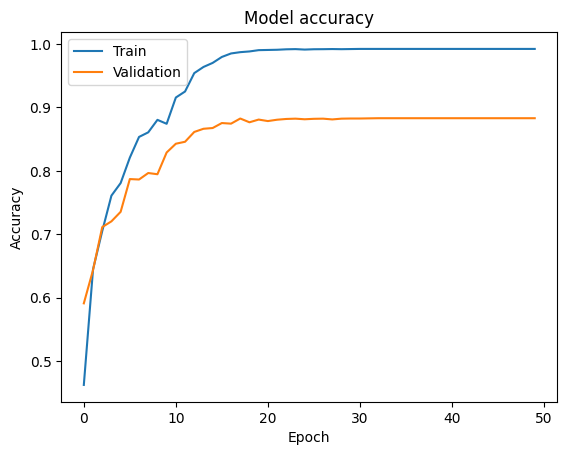

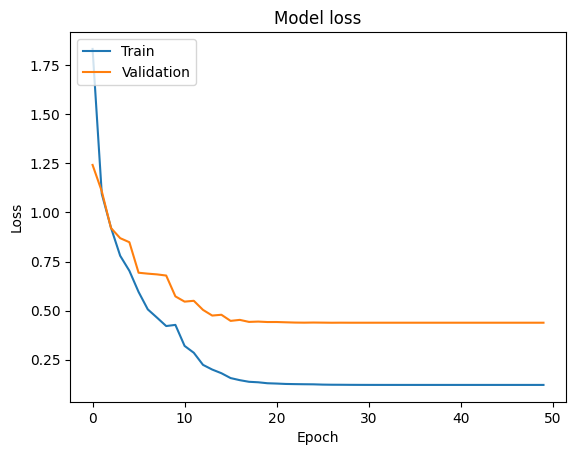

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [13]:
test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])

0.8830952644348145


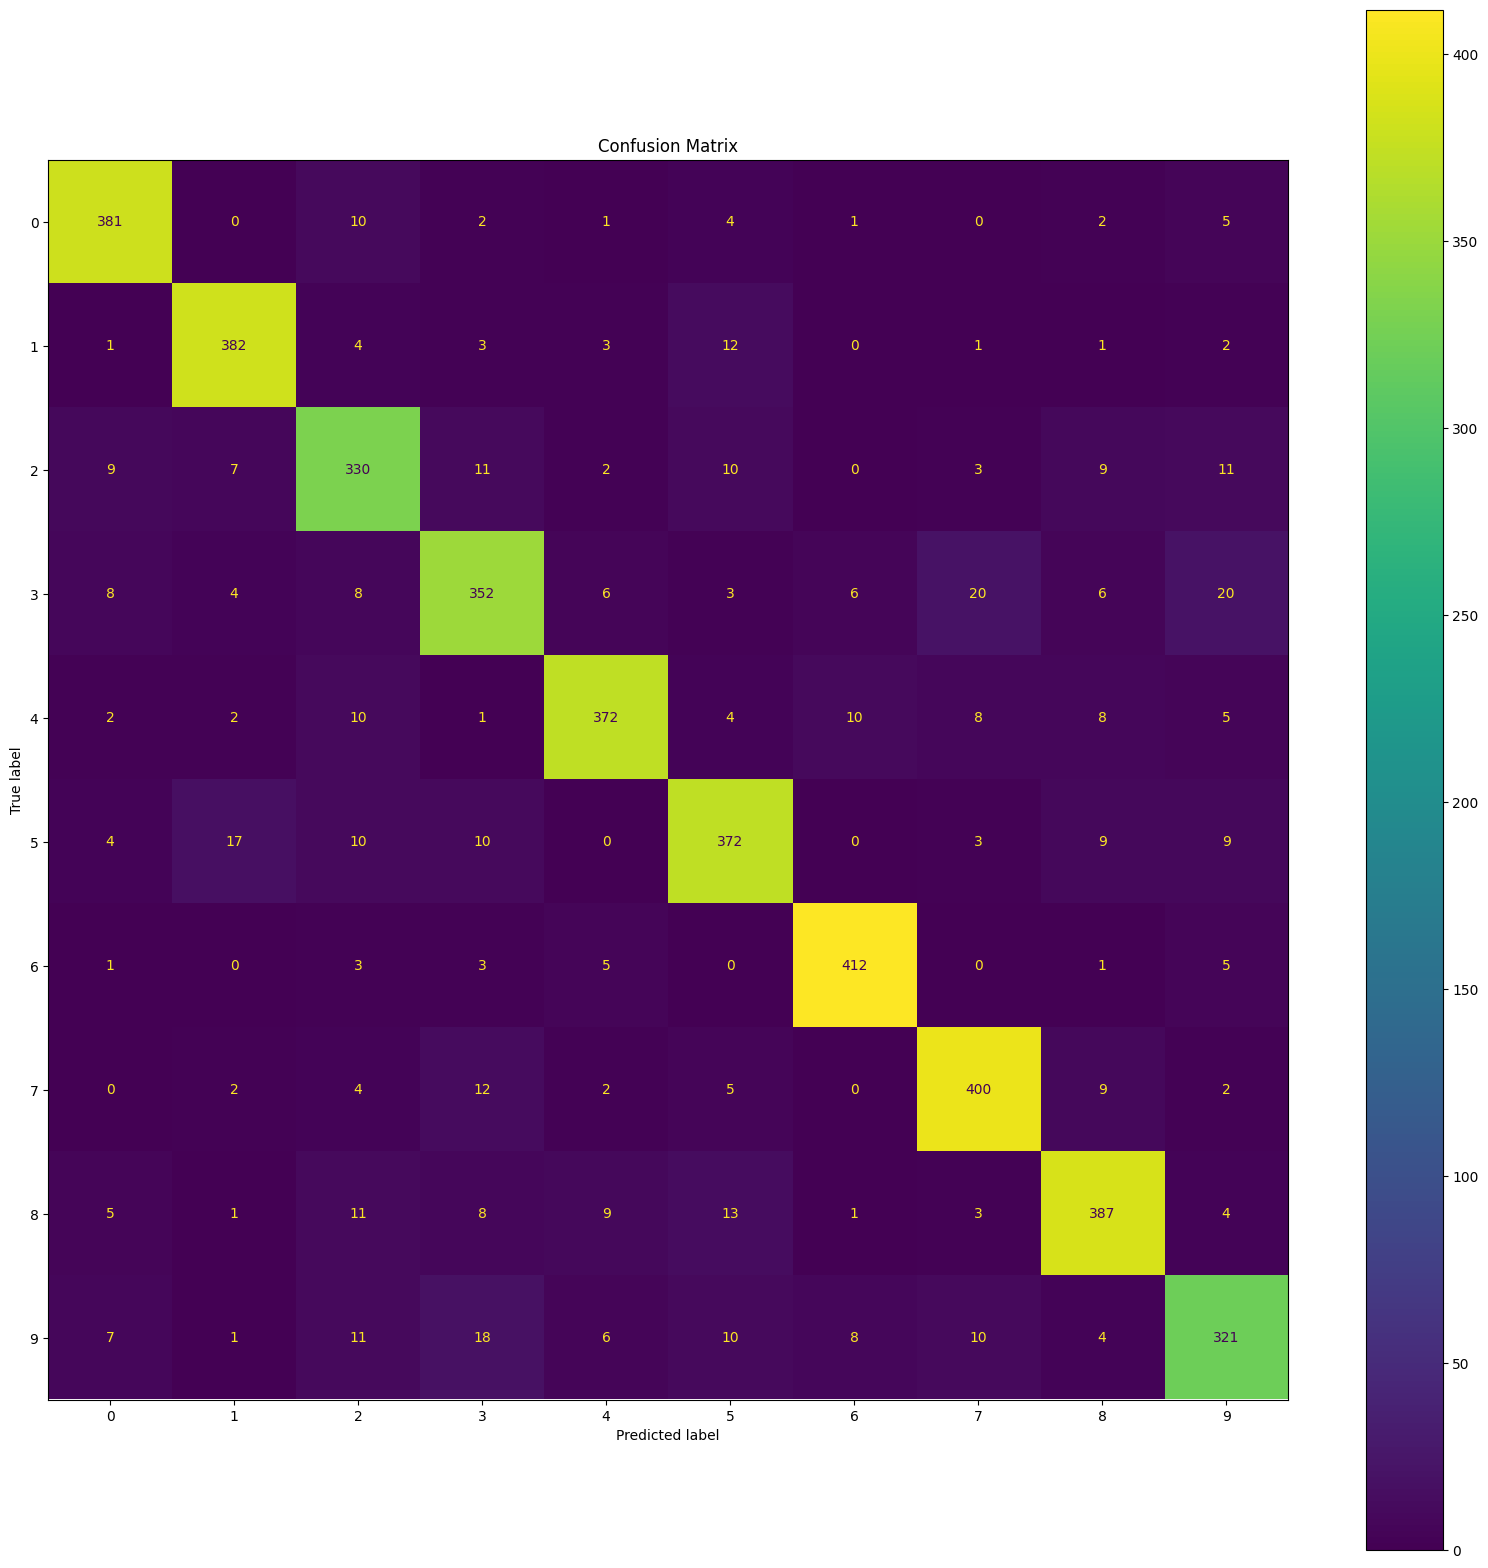

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_prob = model.predict(X_test, verbose=0)

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_prob, axis=1)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(20, 20))
disp.plot(ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8831
Precision: 0.8828
Recall   : 0.8831
F1 Score : 0.8828


In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

y_pred=best_model.predict(X_test)
round_off=np.round_(y_pred)
cm=confusion_matrix(y_test.argmax(axis=1),round_off.argmax(axis=1))
print("Confusion Matrix")
print(cm)

plt.figure(figsize=(20,20))
sns.heatmap(cm,annot=True,fmt="d",cmap='Set3')
plt.title("Confusion Matrix")
plt.ylabel("True class")
plt.xlabel("Predicted class")
plt.show()

In [ ]:
##test this
mydict = {
    'Alternative': 0, 'AlternativeHeavy': 1, 'Electronica': 2, 'Metal': 3, 'Punk': 4,
    'Rap': 5, 'Rave': 6, 'Reggae': 7, 'Rock': 8, 'Stoner': 9
}
xtest = np.array(preprocess_file('test/The Mamas & The Papas - California Dreamin.mp3'))
y_pre =model.predict(xtest)
pred_class = np.argmax(y_pre, axis=1)[0]
#print(pred_class)
for genre, classs in mydict.items():
    if classs == pred_class:
        print("Predicted Genre:", genre)

In [18]:
model.save("THESIS_MFCCTHESIS_MFCC.h5")

In [17]:
#model = tf.keras.models.load_model("THESIS_MFCC.h5")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("THESIS_GTZAN_WAV_MFCCT_INPUTS088.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved Model successfully.")

INFO:tensorflow:Assets written to: C:\Users\gpagk\AppData\Local\Temp\tmpdx4cnw6a\assets


INFO:tensorflow:Assets written to: C:\Users\gpagk\AppData\Local\Temp\tmpdx4cnw6a\assets


Saved Model successfully.


Below Code is based On works of

https://github.com/Manishankar9977/Music-genre-classification/blob/main/music%20gerne%20with%20cnn.ipynb

another PSO trained model is:

      INPUTSHAPE = (16,8,1)
      model = Sequential([

                                layers.Conv2D(55 , (3,3),activation = 'relu',padding='valid', input_shape = INPUTSHAPE),
                                layers.MaxPooling2D(2, padding='same'),
                                layers.Flatten(),
                                layers.Dense(313, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
                                layers.Dense(10 , activation = 'softmax')
      ])

      model.compile(loss = 'categorical_crossentropy', optimizer
      =tf.keras.optimizers.Adam(learning_rate=0.0007842025145903583)
      #= 'adam'
      , metrics =['accuracy'])
      model.summary()
